# AAI-510 M3 Lab Walkthrough — Tree based algorithms

In this lab walkthrough we will build the Decision Tree, Random Forest, and Xgboost, which is a form of ensemble boosted decision trees. We will visualize trees, prune them and study the effects of parameters. Finally, we will analyze the results.

Note this is a very simple dataset, so model performance will be consistent across model versions. This is merely an attempt to introduce the different models and hyperparameter tuning, which will be critical for more complicated problems, including the course assignment

In [2]:
!pip install xgboost

   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
    --------------------------------------- 1.8/124.9 MB 9.1 MB/s eta 0:00:14
   - -------------------------------------- 4.5/124.9 MB 10.7 MB/s eta 0:00:12
   -- ------------------------------------- 6.6/124.9 MB 10.3 MB/s eta 0:00:12
   -- ------------------------------------- 8.9/124.9 MB 10.7 MB/s eta 0:00:11
   --- ------------------------------------ 11.0/124.9 MB 10.3 MB/s eta 0:00:12
   ---- ----------------------------------- 13.4/124.9 MB 10.6 MB/s eta 0:00:11
   ----- ---------------------------------- 16.0/124.9 MB 10.7 MB/s eta 0:00:11
   ----- ---------------------------------- 17.6/124.9 MB 10.5 MB/s eta 0:00:11
   ------ --------------------------------- 19.9/124.9 MB 10.4 MB/s eta 0:00:11
   ------- -------------------------------- 22.3/124.9 MB 10.4 MB/s eta 0:00:10
   ------- -------------------------------- 24.4/124.9 MB 10.5 MB/s eta 0:00:10
   -------- ------------------------------- 27.0/124.9

In [3]:
#@title Loading the required libraries
import pandas as pd # Pandas for data manipulation
import seaborn as sns # Seaborn for visualizing. Note: we will also use one of the data sets
import matplotlib.pyplot as plt # Matplotlib for subplots
%matplotlib inline

from sklearn import tree # Import Tree Classifiers
from sklearn.ensemble import RandomForestClassifier # Import Random Forest Classifiers
from sklearn.model_selection import train_test_split,  RandomizedSearchCV # Import train_test_split function
from sklearn import metrics # Import scikit-learn metrics module for accuracy calculation
from scipy.stats import randint # Generate random numbers
from xgboost import XGBClassifier, plot_importance

### Data Processing

In [6]:
#@title Loading data and viewing it
df = sns.load_dataset('iris')
shap = df.shape
print("Shape of the dataframe (row, col):",shap,"\r\n")

# Do a quick summary of columns and then show examples rows in the dataframe
for col in df.columns:
    print(df[col].describe())
# Print out target variable categorical counts
print(df['species'].value_counts())
df.head()

Shape of the dataframe (row, col): (150, 5) 

count    150.000000
mean       5.843333
std        0.828066
min        4.300000
25%        5.100000
50%        5.800000
75%        6.400000
max        7.900000
Name: sepal_length, dtype: float64
count    150.000000
mean       3.057333
std        0.435866
min        2.000000
25%        2.800000
50%        3.000000
75%        3.300000
max        4.400000
Name: sepal_width, dtype: float64
count    150.000000
mean       3.758000
std        1.765298
min        1.000000
25%        1.600000
50%        4.350000
75%        5.100000
max        6.900000
Name: petal_length, dtype: float64
count    150.000000
mean       1.199333
std        0.762238
min        0.100000
25%        0.300000
50%        1.300000
75%        1.800000
max        2.500000
Name: petal_width, dtype: float64
count        150
unique         3
top       setosa
freq          50
Name: species, dtype: object
setosa        50
versicolor    50
virginica     50
Name: species, dtype: int64


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [7]:
#@title Designating target and features
y = df.species # Target variable
X = df.drop(columns=['species']) # Features by dropping the target column

In [8]:
#@title Splitting dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1) # 70% training and 30% test/valid

# Not relevant for this use case
# But for future reference - and approach to split into valid & test for ensemble models that support validation early stopping natively
# In this example would need to change X_test and y_test above to X_testvalid, y_testvalid to make the below line work

#X_val, X_test, y_val, y_test = train_test_split(X_testvalid, y_testvalid, test_size=0.5, random_state=1) # 70% train, 15% test 15% valid

## Decision Tree

In [9]:
#@title Building the Decision Tree
clf = tree.DecisionTreeClassifier() # Create Decision Tree classifer object
clf = clf.fit(X_train, y_train) # Train Decision Tree Classifer

In [10]:
#@title Evaluating the Tree model
y_hat = clf.predict(X_train) # Predict the response for train dataset

y_pred = clf.predict(X_test) # Predict the response for test dataset

# Compute training and test accuracy
print("Train Accuracy:", metrics.accuracy_score(y_train, y_hat))
print("Test Accuracy:", metrics.accuracy_score(y_test, y_pred))

Train Accuracy: 1.0
Test Accuracy: 0.9555555555555556


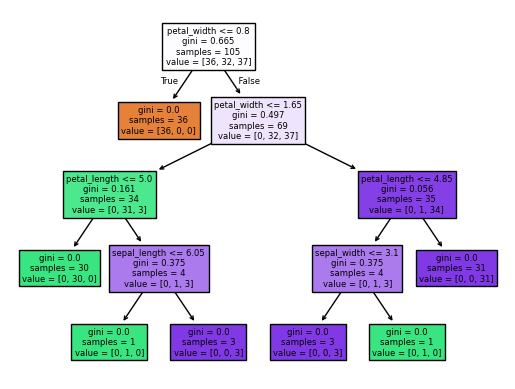

In [11]:
#@title Visualizing the Tree

f_names=list(X.columns) # Feature names
tree.plot_tree(clf, filled=True, feature_names=f_names) # Plot the tree
plt.show() # Show without the rules in plain text

### Tuning the Tree

There are several parameters that can be adjusted to obtain a suitable tree such as ``criterion``, ``max_depth``, ``min_samples_leaf``, etc. Typically, the tree depth has the greatest impact on accuracy and generalization

Train Accuracy: 0.9809523809523809
Test Accuracy: 0.9555555555555556


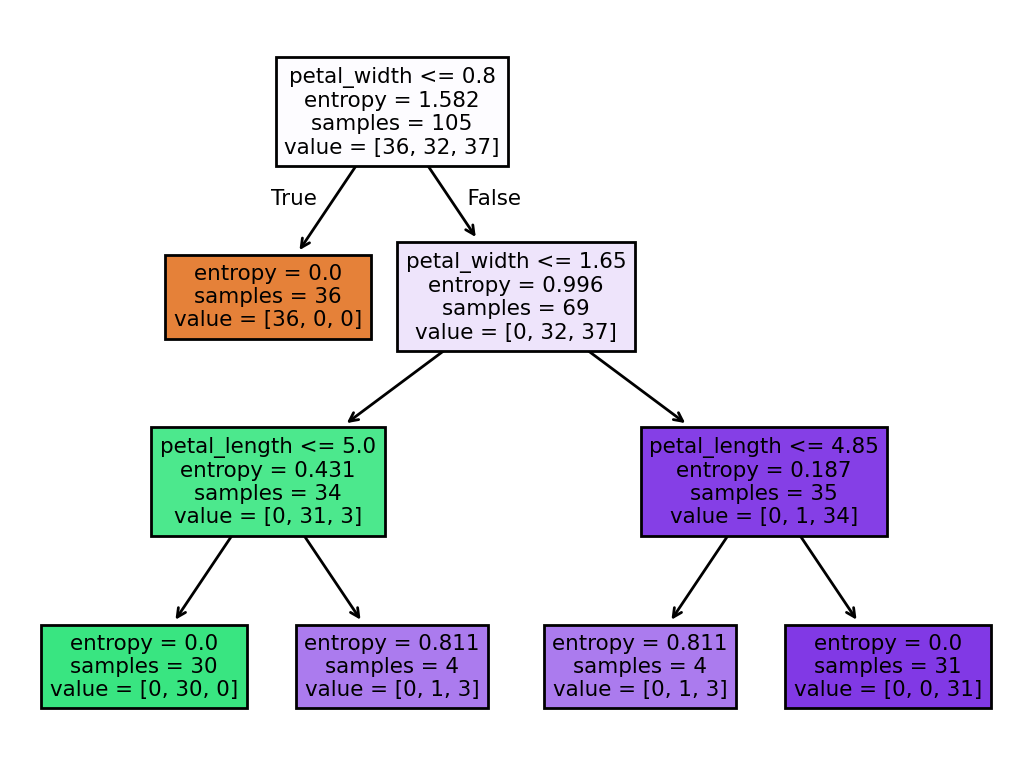

In [12]:
# Create Decision Tree classifer object by spefifying parameters
# Try using max_depth=3, min_samples_split=100, min_samples_leaf=2, criterion="entropy"
clf = tree.DecisionTreeClassifier(max_depth=3, min_samples_leaf=2, criterion='entropy') 

# Train and test the classifier
clf = clf.fit(X_train, y_train) # Train Decision Tree Classifer
y_hat = clf.predict(X_train) # Predict the response for train dataset
y_pred = clf.predict(X_test) # Predict the response for test dataset

# Compute training and test accuracy
print("Train Accuracy:", metrics.accuracy_score(y_train, y_hat))
print("Test Accuracy:", metrics.accuracy_score(y_test, y_pred))

plt.rcParams['figure.dpi'] = 200 # To increase the resolution from 100dpi to 200dpi

# Plot the tree
f_names=list(X.columns) # Feature names
tree.plot_tree(clf, filled=True, feature_names=f_names) # Plot the tree
plt.show() # Show without the rules in plain text

## Random Forest
Single trees are prone to bias, instability and overfitting. Randowm forests remedey these shortcomings by building an ensamble of deep trees on different subsets of the training data.

The iris dataset is an extremely simple example so we are able to get good performance with a single tree, but that will not stay true with other more complex datasets

In [13]:
#@title Building the Random Forest

rf = RandomForestClassifier(random_state=100) # Create Fandom Forest classifer object
rf = rf.fit(X_train, y_train) # Train Random Forest Classifer

In [14]:
#@title Evaluating the RF model
y_hat = rf.predict(X_train) # Predict the response for train dataset

y_pred = rf.predict(X_test) # Predict the response for test dataset

# Compute training and test accuracy
print("Train Accuracy:", metrics.accuracy_score(y_train, y_hat))
print("Test Accuracy:", metrics.accuracy_score(y_test, y_pred))

Train Accuracy: 1.0
Test Accuracy: 0.9555555555555556


In [15]:
#@title Visualizing few trees of the RF

f_names=list(X.columns) # Feature names
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(10,2), dpi=3000) # Setup the 1x5 grid for ploting the trees
for index in range(0, 5): # Iterate through the first five trees (of 100)
  tree.plot_tree(rf.estimators_[index], feature_names=f_names, filled = True, ax=axes[index]); # Plot the tree
  axes[index].set_title('Estimator: ' + str(index), fontsize = 11) # Print title

In [16]:
#@title Tuning the RF
# Create RF classifer object by spefifying parameters
# Try using n_estimators=200, max_depth=2
rf = RandomForestClassifier(n_estimators=200, max_depth=2, random_state=0) # Create Random Forest classifer object
rf = rf.fit(X_train, y_train) # Train Random Forest Classifer

# Train and test the classifier
rf = rf.fit(X_train, y_train) # Train Decision Tree Classifer
y_hat = rf.predict(X_train) # Predict the response for train dataset
y_pred = rf.predict(X_test) # Predict the response for test dataset

# Compute training and test accuracy
print("Train Accuracy:", metrics.accuracy_score(y_train, y_hat))
print("Test Accuracy:", metrics.accuracy_score(y_test, y_pred))

Train Accuracy: 0.9619047619047619
Test Accuracy: 0.9555555555555556


In [17]:
#@title Hyperparameter search
param_dist = {'n_estimators': randint(50,500), 'max_depth': randint(1,20)} # Search ranges
rf = RandomForestClassifier() # Create a random forest classifier
rand_search = RandomizedSearchCV(rf, param_distributions=param_dist, n_iter=5, cv=5) # Use random search to find the best hyperparameters
rand_search.fit(X_train, y_train) # Fit the random search object to the training data

# Print the best hyperparameters
print('Best hyperparameters:',  rand_search.best_params_)

best_rf = rand_search.best_estimator_ # Capture the best model
y_hat = best_rf.predict(X_train) # Predict the response for train dataset
y_pred = best_rf.predict(X_test) # Predict the response for test dataset

# Compute training and test accuracy
print("Train Accuracy:", metrics.accuracy_score(y_train, y_hat))
print("Test Accuracy:", metrics.accuracy_score(y_test, y_pred))

Best hyperparameters: {'max_depth': 11, 'n_estimators': 450}
Train Accuracy: 1.0
Test Accuracy: 0.9555555555555556


Precision: 0.9555555555555556
Recall: 0.9555555555555556


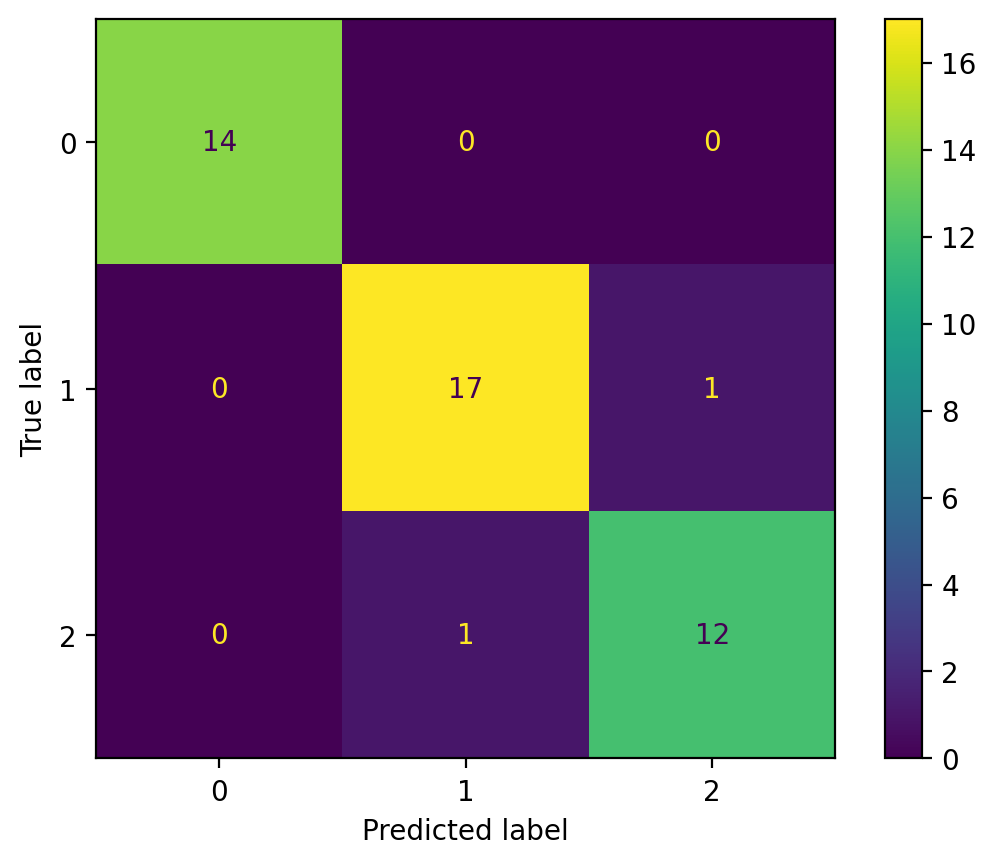

In [18]:
#@title More Evaluation Metrics

print("Precision:", metrics.precision_score(y_test, y_pred, average = 'weighted')) # Note - multi-class problem so not straight forward!
print("Recall:", metrics.recall_score(y_test, y_pred, average = 'weighted')) # Note - multi-class problem so not straight forward!

# Create the confusion matrix
cm = metrics.confusion_matrix(y_test, y_pred)
metrics.ConfusionMatrixDisplay(confusion_matrix=cm).plot();



# XGBOOST

XGBoost is a powerful ensemble approach that is leveraged in industry frequently for tabular problems. It has a more involved hyperparameter tuning process, but often can get superior performance relative to RandomForest

In [19]:
# Need to convert categorical to numeric in target variable

y_xgb = y.astype('category').cat.codes

# Splitting dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y_xgb, test_size=0.3, random_state=1) # 70% training and 30% test/valid

In [20]:
bst = XGBClassifier(enable_categorical=True).fit(X_train, y_train)
y_hat = bst.predict(X_train) # Predict the response for train dataset
y_pred = bst.predict(X_test) # Predict the response for test dataset

# Compute training and test accuracy
print("Train Accuracy:", metrics.accuracy_score(y_train, y_hat))
print("Test Accuracy:", metrics.accuracy_score(y_test, y_pred))

Train Accuracy: 1.0
Test Accuracy: 0.9333333333333333


In [21]:
# Hyperparameter optimization
# Experiment with learning rate, number of trees, subsample

bst_hyp = XGBClassifier(enable_categorical=True,
                        learning_rate = 0.05, 
                        max_depth = 10, 
                        n_estimators = 20, 
                        objective='multi:softmax', 
                        num_class=3,
                        subsample = 0.8) # Lowering subsample will reduce data available in each tree
bst_hyp_mod = bst_hyp.fit(X_train, y_train)
                        
y_hat = bst_hyp_mod.predict(X_train) # Predict the response for train dataset
y_pred = bst_hyp_mod.predict(X_test) # Predict the response for test dataset

# Compute training and test accuracy
print("Train Accuracy:", metrics.accuracy_score(y_train, y_hat))
print("Test Accuracy:", metrics.accuracy_score(y_test, y_pred))                     

Train Accuracy: 0.9809523809523809
Test Accuracy: 0.9555555555555556


<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

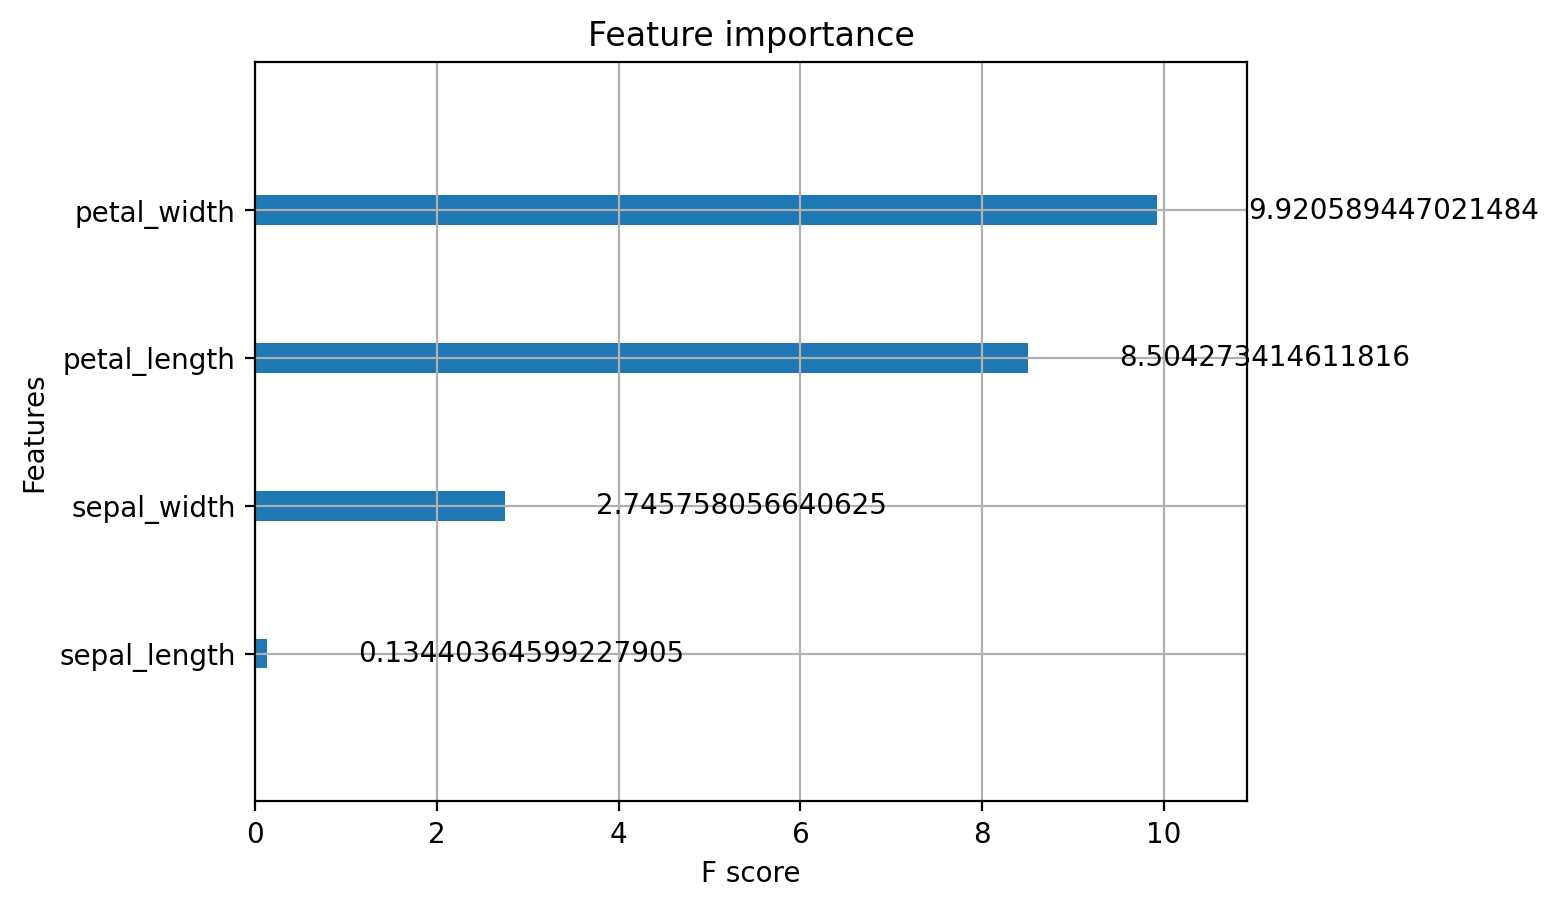

In [22]:
# Feature Importance - helpful way to understand what is driving predictions in tree-based models
# 'gain' shows the average gain of splits which use the feature, 'weight' shows the number of time a feature appears in a tree
plot_importance(bst_hyp_mod, importance_type = 'gain') # try 'weight' to see if the interpretation changes